[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/assignments/assignment_combined_5_6.ipynb)

# Assignment 5 & 6: HRTEM Simulation and CTF Analysis

In this assignment, you will use the `abTEM` package to perform a multislice High-Resolution Transmission Electron Microscopy (HRTEM) simulation. You will build an atomic model, calculate its projected potential, simulate the electron wave propagation, and apply different Contrast Transfer Functions (CTFs) to understand how microscope parameters affect the final image.

**Name:** 
Elise M. Etrheim

**Submission Date:** 
11 March 2026

## Learning Objectives
1. Understand the multislice algorithm for HRTEM simulation.
2. Explore the effects of the Contrast Transfer Function (CTF), including spherical aberration ($C_s$) and defocus ($\Delta f$).
3. Analyze the impact of aberration correction and noise on image quality.

---

## Part 1: Setup and Building the Atomic Model

First, we import the necessary libraries and build our atomic model. We will use a Silicon Nitride (Si$_3$N$_4$) crystal structure.

In [1]:
%matplotlib inline

import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

print(f"abTEM version: {abtem.__version__}")
print(f"NumPy version: {np.__version__}") # Downgraded < 2 to allow for downstream analysis

abTEM version: 1.0.5
NumPy version: 1.26.4


### Define the Si$_3$N$_4$ Structure
We use the Atomic Simulation Environment (`ase`) to define the unit cell by providing the atomic positions and cell dimensions.

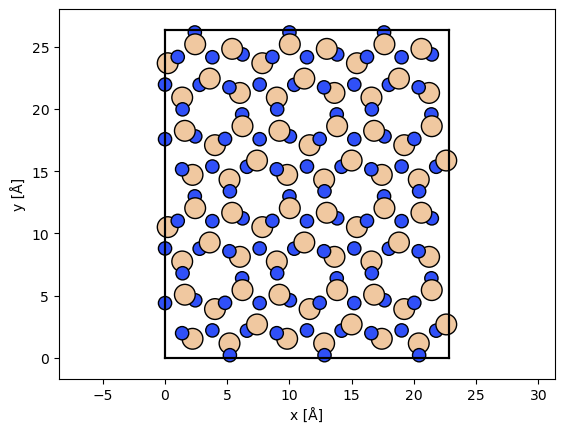

In [2]:
structure = ase.Atoms(
    'Si6N8',
    positions=[
      (4.015308131006949, 3.9110253242355126, 2.1788993100000003),
      (2.422878997737693, -1.15285715796029, 0.72629977),
      (5.3947013511357, -1.5218461833564767, 0.72629977),
      (2.2098430845971873, 1.521846183356477, 2.1788993100000003),
      (5.181665437995193, 1.1528571579602902, 2.1788993100000003),
      (3.5892363047259375, -3.9110253242355126, 0.72629977),
      (3.8022722178664434, 2.195242888517426, 2.1788993100000003),
      (3.802272217866444, -2.1952428885174267, 0.72629977),
      (6.2321062558996125, -1.9713791971906662, 2.1788993100000003),
      (4.8233175932090955, 4.411472738097657, 0.72629977),
      (5.211060880556961, 0.20287673026395847, 0.72629977),
      (2.3934835551759255, -0.20287673026395803, 2.1788993100000003),
      (1.3724381798332734, 1.9713791971906653, 0.72629977),
      (2.781226842523792, -4.411472738097657, 2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

# The multislice algorithm requires an orthogonal input cell.
structure_orthogonal = abtem.atoms.orthogonalize_cell(structure) # Slight modification due to more recent abTEM version

# Visualize the orthogonalized structure (tiled 3x2x6 for visualization)
abtem.show_atoms(structure_orthogonal * (3,2,6), plane='xy');

---

## Part 2: Calculate Projected Potentials

**TASK 1:** Calculate the projected potentials for the structure.
1. Create a `FrozenPhonons` object using the orthogonalized structure tiled by `(3, 2, 17)`. This gives a thickness of ~5 nm. Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N.
2. Create a `Potential` object using the frozen phonons, with a sampling of 0.1 Å, slice thickness of 2.0 Å, and the 'kirkland' parametrization.
3. Plot the mean-projected potential.

[########################################] | 100% Completed | 2.72 ss


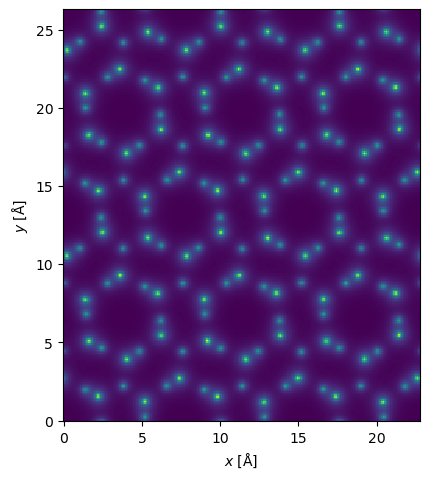

In [3]:
# TASK 1: Create FrozenPhonons
# Tile the structure by (3, 2, 17) to get ~5 nm thickness
# Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N
frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (3, 2, 17),
    num_configs=8,
    sigmas={'Si': 0.1, 'N': 0.1},  # thermal displacement in Å
)

# TASK 1: Create the Potential object
# Use sampling=0.1 Å, slice_thickness=2.0 Å, and the 'kirkland' parametrization
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,           # real-space sampling in Å/pixel
    slice_thickness=2.0,    # thickness of each projected slice in Å
    parametrization='kirkland',
)

# TASK 1: Plot the mean projected potential
# .project() collapses along z; .show() displays it
potential.project().show(cmap='viridis');


**Summary:**

- Constructed frozen phonon configurations to simulate thermal motion.
- Computed projected electrostatic potential using the Kirkland scattering parametrization.
- Averaged over multiple phonon configurations, ultimately generating the projected potential slices required for multislice TEM simulation.

---

## Part 3: HRTEM Plane Wave Multislice Simulation

**TASK 2:** Perform the multislice simulation.
1. Initialize a `PlaneWave` with an energy of 300 keV.
2. Run the `multislice` algorithm using the potential you calculated.
3. Plot the mean intensity of the exit waves.

[########################################] | 100% Completed | 1.42 ss


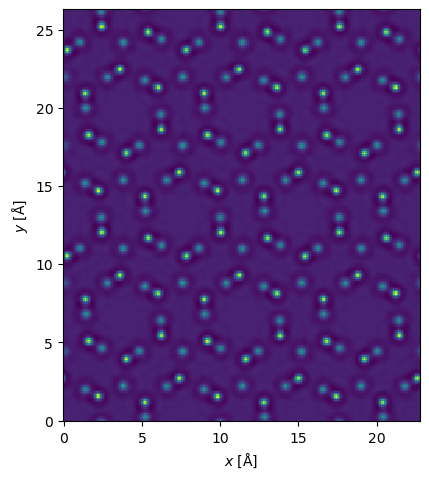

In [4]:
# TASK 2: Initialize the PlaneWave with 300 keV energy
wave = abtem.PlaneWave(energy=300e3)  # energy in eV

# TASK 2: Run the multislice simulation
# This propagates the wave through each slice of the potential
exit_waves = wave.multislice(potential)

# TASK 2: Plot the mean intensity of the exit waves
# .intensity() computes |ψ|², .mean(0) averages over frozen phonon configs
exit_waves.intensity().mean(0).show(cmap='viridis');


**Summary:**

- Initialized a 300 keV plane electron wave.
- Propagated the wave through the sample using the multislice algorithm.
- Computed the exit wave intensity, simulating electron scattering through a ~ 5 nm thick Si₃N₄ specimen.

---

## Part 4: Contrast Transfer Function (CTF)

The exit wave represents the electron wave immediately after leaving the sample. To simulate the final image, we must apply the Contrast Transfer Function (CTF) of the microscope.

**TASK 3:** Define and apply different CTFs.
1. Define an **uncorrected CTF** with $C_{10} = -600$ Å (defocus) and $C_{30} = 1.3 \times 10^7$ Å ($C_s = 1.3$ mm).
2. Define an **aberration-corrected CTF** with $C_{10} = 30$ Å and $C_{30} = -8 \times 10^4$ Å.
3. Plot both CTFs to compare them.
4. Apply both CTFs to your `exit_waves` and plot the resulting mean image intensities.

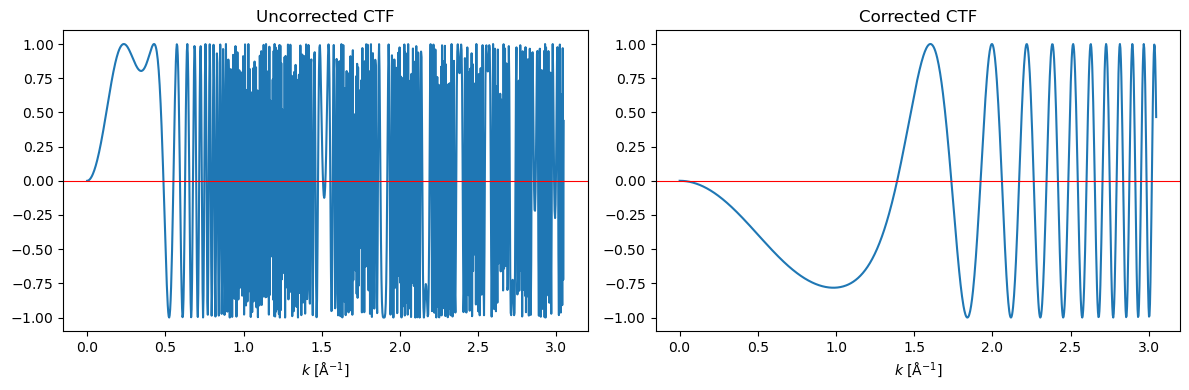

In [24]:
# TASK 3: Contrast Transfer Functions (CTF)

energy = 300e3  # accelerating voltage (eV)

# Shared simulation grid
grid = dict(gpts=(512, 512), sampling=(0.02, 0.02))

# Aberration definitions
aberrations = {
    "Uncorrected": {"C10": -600, "C30": 1.3e7},   # conventional TEM (Cs ≈ 1.3 mm)
    "Corrected":   {"C10": 30,   "C30": -8e4},    # Cs-corrected microscope (Cs is very small, defocus is near zero)
}

# Build CTF objects
ctfs = {
    name: abtem.CTF(
        energy=energy,
        aberration_coefficients=params,
        **grid
    )
    for name, params in aberrations.items()
}

# Plot CTF profiles
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, ctf) in zip(axes, ctfs.items()):
    ctf.profiles(max_angle=60).show(ax=ax, units="mrad")
    ax.axhline(0, color="red", linewidth=0.8)
    ax.set_title(f"{name} CTF")

plt.tight_layout()

[########################################] | 100% Completed | 1.34 ss
[########################################] | 100% Completed | 1.35 ss


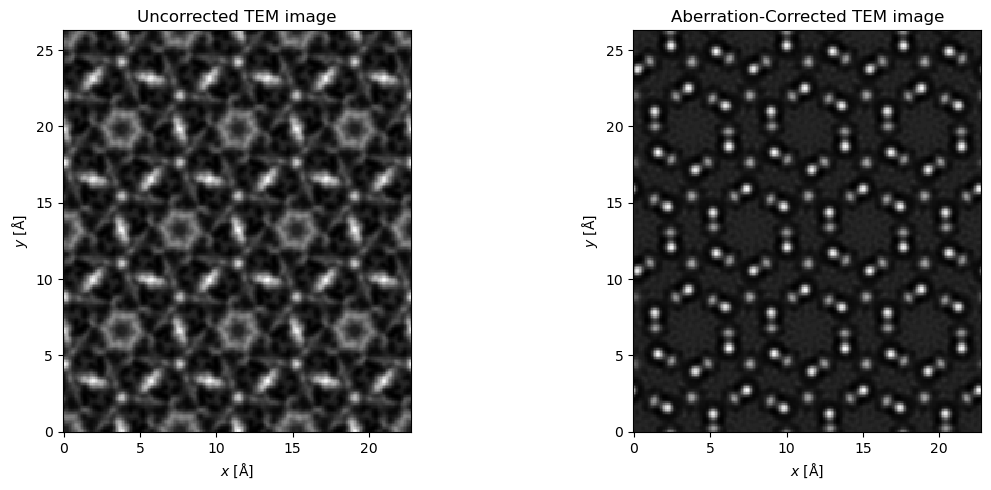

In [25]:
# TASK 3d: Apply each CTF to the exit waves
# .apply_ctf() convolves the exit wave with the CTF in Fourier space
image_uncorrected = exit_waves.apply_ctf(ctf_uncorrected)
image_corrected   = exit_waves.apply_ctf(ctf_corrected)

# TASK 3d: Plot the resulting mean image intensities side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

image_uncorrected.intensity().mean(0).show(cmap='gray', ax=axes[0])
axes[0].set_title('Uncorrected TEM image')

image_corrected.intensity().mean(0).show(cmap='gray', ax=axes[1])
axes[1].set_title('Aberration-Corrected TEM image')

plt.tight_layout()
plt.show()


**Summary:**

- Defined two microscope models: (a) conventional TEM (Cs ≈ 1.3 mm) and (b) aberration-corrected TEM.
- Visualized their CTFs.
- Applied each CTF to the exit wave to demonstrate how lens aberrations affect image contrast and resolution.

---

## Part 5: Noise and Dose

Real TEM images are affected by Poisson noise due to the finite electron dose.

**TASK 4:** Apply Poisson noise to your images.
1. Use `abtem.noise.poisson_noise` to apply a dose of $100$ $e^-$/Å$^2$ to your aberration-corrected image.
2. Plot the noisy image alongside the noiseless one for comparison.

[########################################] | 100% Completed | 1.32 ss
[########################################] | 100% Completed | 1.46 ss


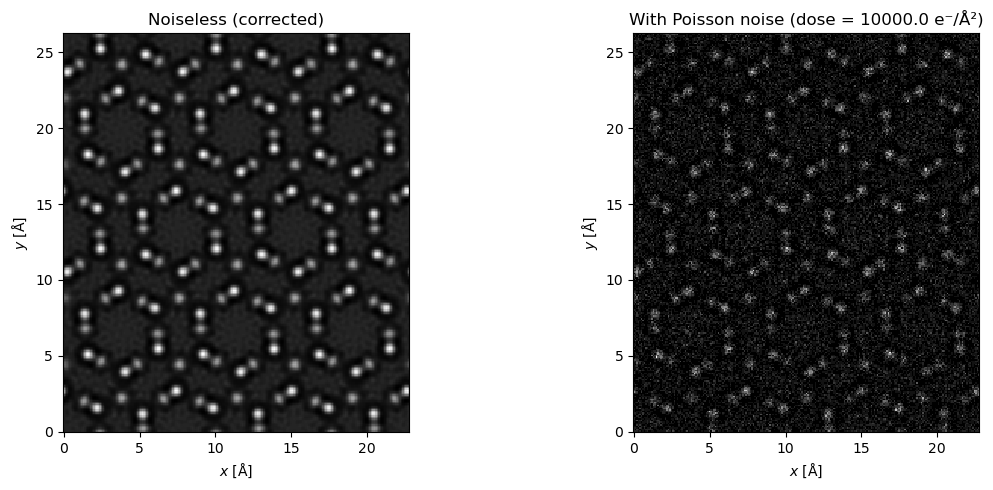

In [26]:
# TASK 4: Apply Poisson noise to the aberration-corrected image
# dose is in electrons per Å²; lower dose → more noise
dose = 1e4 # e⁻/Å²

# Get the noiseless mean intensity image
noiseless_image = image_corrected.intensity().mean(0)

# Convert dose → electrons per pixel
pixel_area = noiseless_image.sampling[0] * noiseless_image.sampling[1]
n_electrons = dose * pixel_area

# Apply Poisson noise
noisy_image = noiseless_image.poisson_noise(n_electrons)

# Plot noiseless vs noisy images
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
noiseless_image.show(cmap='gray', ax=axes[0])
axes[0].set_title('Noiseless (corrected)')

noisy_image.show(cmap='gray', ax=axes[1])
axes[1].set_title(f'With Poisson noise (dose = {dose} e⁻/Å²)')

plt.tight_layout()
plt.show()

Due to version mis-match, the above code was slightly altered, and the simulation now uses a very small pixel size, so a larger dose was needed to produce a noisy image that still remains interpretable.

[########################################] | 100% Completed | 1.32 ss
[########################################] | 100% Completed | 1.37 ss
[########################################] | 100% Completed | 1.45 ss
[########################################] | 100% Completed | 1.34 ss


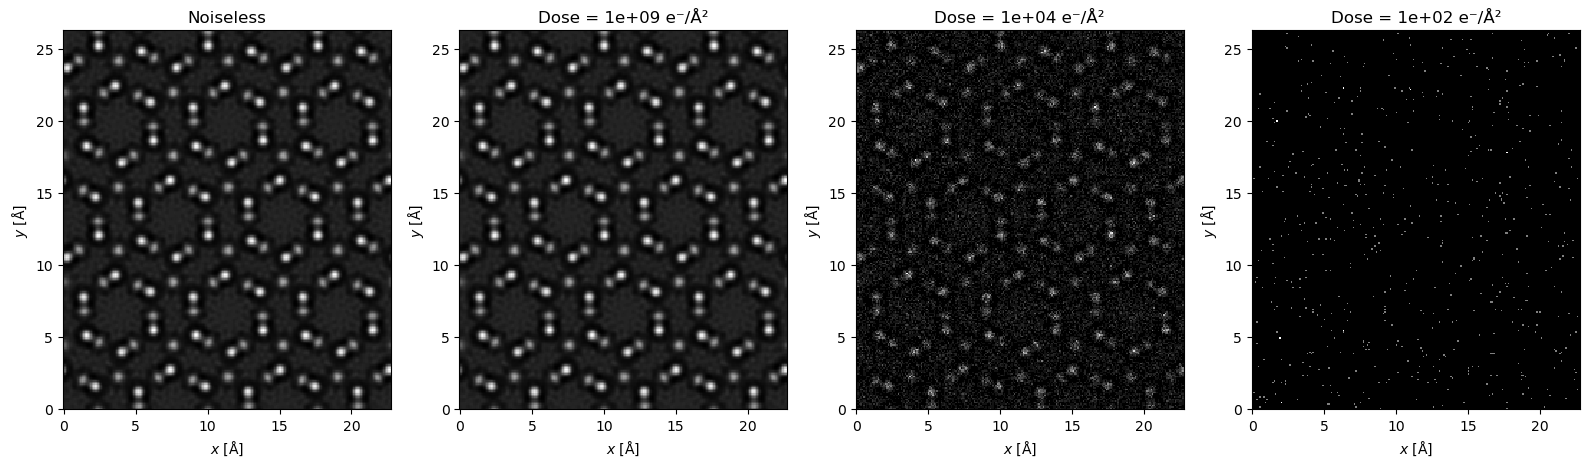

In [27]:
# TASK 4: Apply Poisson noise to the aberration-corrected image
# dose is in electrons per Å²; lower dose → more noise
doses = [1e9, 1e4, 100]  # high → low dose

# Get the noiseless mean intensity image
noiseless_image = image_corrected.intensity().mean(0)

# Convert dose → electrons per pixel
pixel_area = noiseless_image.sampling[0] * noiseless_image.sampling[1]

# Generate noisy images
noisy_images = []
for dose in doses:
    n_electrons = dose * pixel_area
    noisy_images.append(noiseless_image.poisson_noise(n_electrons))

# Plot results
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# Noiseless reference
noiseless_image.show(cmap='gray', ax=axes[0])
axes[0].set_title("Noiseless")

# Noisy versions
for i, dose in enumerate(doses):
    noisy_images[i].show(cmap='gray', ax=axes[i+1])
    axes[i+1].set_title(f"Dose = {dose:.0e} e⁻/Å²")

plt.tight_layout()
plt.show()

**Summary:**

- Converted electron dose to electrons per pixel
- Added Poisson counting noise to the corrected TEM image to simulate realistic detector noise from finite electron dose.

---

# Task 6: Self-Reflection

Based on your simulations above, answer the following questions:

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?
- Why do we see sharper atomic columns in the aberration-corrected image?

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM?
- What is the significance of the Scherzer defocus?

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image?
- What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?

### Your Answers:

#### **1. Contrast Transfer Function (CTF):**

**How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?**
The uncorrected CTF oscillates strongly and reaches its first zero at relatively low spatial frequency due to spherical aberration. This limits the range of spatial frequencies that contribute constructively to the image. In contrast, the aberration-corrected CTF maintains positive transfer to much higher spatial frequencies with fewer oscillations, allowing higher-resolution structural information to be transmitted.

**Why do we see sharper atomic columns in the aberration-corrected image?**
Aberration correction reduces spherical aberration, which allows higher spatial frequencies corresponding to atomic-scale features to be transferred without phase distortions. As a result, fine structural details such as atomic columns are reproduced with higher contrast and sharper resolution.

#### **2. Defocus and Contrast:**

**Why don't we typically image at exactly zero defocus in a conventional TEM?**
At zero defocus, the CTF suppresses most low and intermediate spatial frequencies, producing very weak phase contrast. As a result, atomic-scale features become difficult to detect. Defocusing the objective lens shifts the CTF so that important spatial frequencies are transferred with stronger contrast.

**What is the significance of the Scherzer defocus?**
The scherzer defocus is the defocus value that maximizes the transfer of spatial frequencies before the first CTF zero while minimizing phase distortions caused by spherical aberration. It therefore provides near-optimal contrast and resolution for conventional TEM imaging.

#### **3. Simulation vs. Reality:**

**How does adding Poisson noise change interpretability of the image?**
Poisson noise introduces statistical intensity fluctuations due to the finite number of detected electrons. This reduces the signal-to-noise ratio and can obscure weak structural features, making atomic columns and lattice fringes more difficult to interpret.

**What other experimental factors might degrade the quality of a real HRTEM image?**
Several additional factors can degrade image quality, including sample drift, mechanical vibrations, beam-induced specimen damage, chromatic aberration, detector noise, imperfect aberration correction, and specimen thickness variations.

#### **4. Multislice Algorithm:**

**Why is the multislice method necessary for a 5 nm thick sample rather than using a single projected potential?**
For thicker speciments such as 5 nm, electrons undergo multiple scattering events as they propagate through the sample. The multislice method accounts for this dynamical scattering by sequentially propagating the electron wave through thin potential slices. A single projected potential assumes weak (kinematic) scattering and cannot accurately describe the complex wave interactions that occur in thicker samples.